# Generate `param_times.json`

In [1]:
import pandas as pd
from ambdes import fit_config, plot_metric_kde
from rich import print
import json
from sim_tools.distributions import DistributionRegistry

In [2]:
TIME_DATA_PATH = "../data/times.csv"
PARAM_TIMES_PATH = "../data/param_times.json"
CHOSEN_TIME_DIST_PATH = "../data/chosen_time_distributions.json"

# Import raw time data
time_data = pd.read_csv(TIME_DATA_PATH)

# Import dictionary detailing chosen distributions and relevant columns
with open(CHOSEN_TIME_DIST_PATH) as f:
    chosen_time_dist = json.load(f)
print(chosen_time_dist)

{
    'mobilisation_time': {'dist': 'Weibull', 'column': 'C0001_Mobilisation_Duration'},
    'time_to_scene': {'dist': 'Erlang', 'column': 'C0004_MobilisationToScene_Duration'},
    'on_scene_time': {'dist': 'Lognormal', 'column': 'C0007_OnScene_Duration'},
    'time_to_hospital': {'dist': 'Gamma', 'column': 'C0172_SceneToDestination_Duration'},
    'handover_time': {'dist': 'Lognormal', 'column': 'C0012_Handover_Duration'},
    'wrap_up_time': {'dist': 'Gamma', 'column': 'C0171_WrapUp_Duration'}
}

In [3]:
# Generate config
config = fit_config(time_data=time_data, metric_config=chosen_time_dist)

print(config)

# Save to JSON file
with open(PARAM_TIMES_PATH, "w") as fp:
    json.dump(config, fp, indent=2)

{
    'mobilisation_time': {
        'C1': {
            'class_name': 'Weibull',
            'params': {'alpha': np.float64(1.6230794050180255), 'beta': np.float64(55.33969658257871)}
        },
        'C2': {
            'class_name': 'Weibull',
            'params': {'alpha': np.float64(2.5754152388808462), 'beta': np.float64(72.15648899509338)}
        },
        'C3': {
            'class_name': 'Weibull',
            'params': {'alpha': np.float64(3.855530464774515), 'beta': np.float64(83.63968068997178)}
        },
        'C4': {
            'class_name': 'Weibull',
            'params': {'alpha': np.float64(6.287914000570807), 'beta': np.float64(91.88218869470683)}
        }
    },
    'time_to_scene': {
        'C1': {
            'class_name': 'Erlang',
            'params': {'mean': np.float64(499.9418859036288), 'stdev': np.float64(289.4738923884731)}
        },
        'C2': {
            'class_name': 'Erlang',
            'params': {'mean': np.float64(638.1097445299112), 'stdev': np.float64(272.44876482864544)}
        },
        'C3': {
            'class_name': 'Erlang',
            'params': {'mean': np.float64(756.010430729669), 'stdev': np.float64(233.13194778804214)}
        },
        'C4': {
            'class_name': 'Erlang',
            'params': {'mean': np.float64(848.201906134871), 'stdev': np.float64(180.96496349643516)}
        }
    },
    'on_scene_time': {
        'C1': {
            'class_name': 'Lognormal',
            'params': {'mean': np.float64(2506.395073655635), 'stdev': np.float64(1443.181625142462)}
        },
        'C2': {
            'class_name': 'Lognormal',
            'params': {'mean': np.float64(3171.3297875732337), 'stdev': np.float64(1361.7408615658346)}
        },
        'C3': {
            'class_name': 'Lognormal',
            'params': {'mean': np.float64(3780.5453592092576), 'stdev': np.float64(1165.2150520759853)}
        },
        'C4': {
            'class_name': 'Lognormal',
            'params': {'mean': np.float64(4240.604092583694), 'stdev': np.float64(902.4410312931393)}
        }
    },
    'time_to_hospital': {
        'C1': {
            'class_name': 'Gamma',
            'params': {'alpha': 1.8062634068000836, 'beta': np.float64(557.2743416485248)}
        },
        'C2': {
            'class_name': 'Gamma',
            'params': {'alpha': 4.4671578582551525, 'beta': np.float64(286.8057491561533)}
        },
        'C3': {
            'class_name': 'Gamma',
            'params': {'alpha': 8.828882994656915, 'beta': np.float64(170.514827000873)}
        },
        'C4': {
            'class_name': 'Gamma',
            'params': {'alpha': 18.916608595745952, 'beta': np.float64(89.78999339247783)}
        }
    },
    'handover_time': {
        'C1': {
            'class_name': 'Lognormal',
            'params': {'mean': np.float64(1490.4834125114776), 'stdev': np.float64(866.3764211083165)}
        },
        'C2': {
            'class_name': 'Lognormal',
            'params': {'mean': np.float64(1924.0623570204457), 'stdev': np.float64(819.9778561644747)}
        },
        'C3': {
            'class_name': 'Lognormal',
            'params': {'mean': np.float64(2267.3613387978144), 'stdev': np.float64(698.1574975849574)}
        },
        'C4': {
            'class_name': 'Lognormal',
            'params': {'mean': np.float64(2544.5645563030594), 'stdev': np.float64(541.4468002530408)}
        }
    },
    'wrap_up_time': {
        'C1': {
            'class_name': 'Gamma',
            'params': {'alpha': 1.7696472723339476, 'beta': np.float64(280.75953377544676)}
        },
        'C2': {
            'class_name': 'Gamma',
            'params': {'alpha': 4.386504660291272, 'beta': np.float64(145.49681072996276)}
        },
        'C3': {
            'class_name': 'Gamma',
            'params': {'alpha': 8.903169331601253, 'beta': np.float64(85.0234799782704)}
        },
        'C4': {
            'class_name': 'Gamma',
            'params': {'al

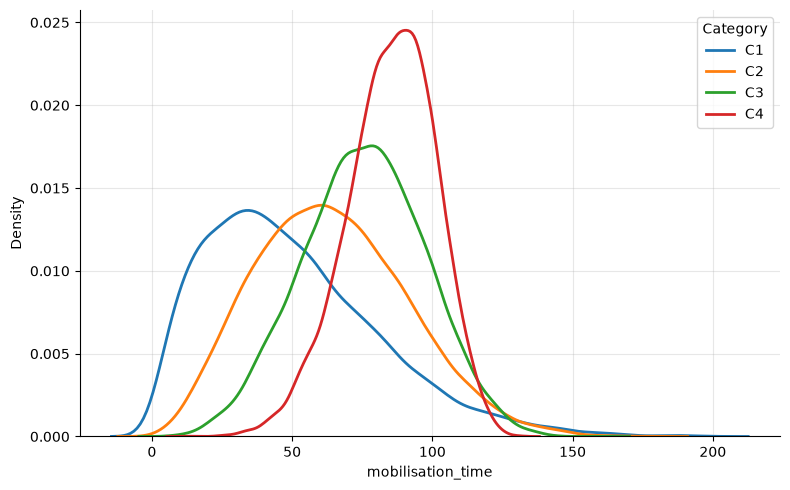

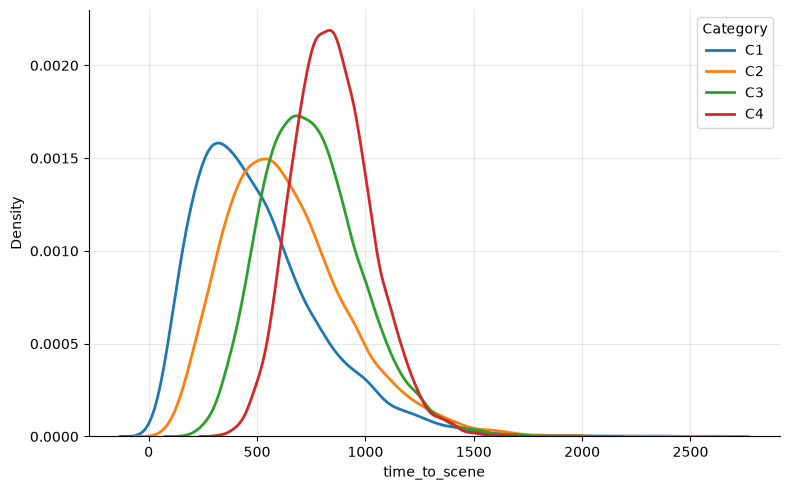

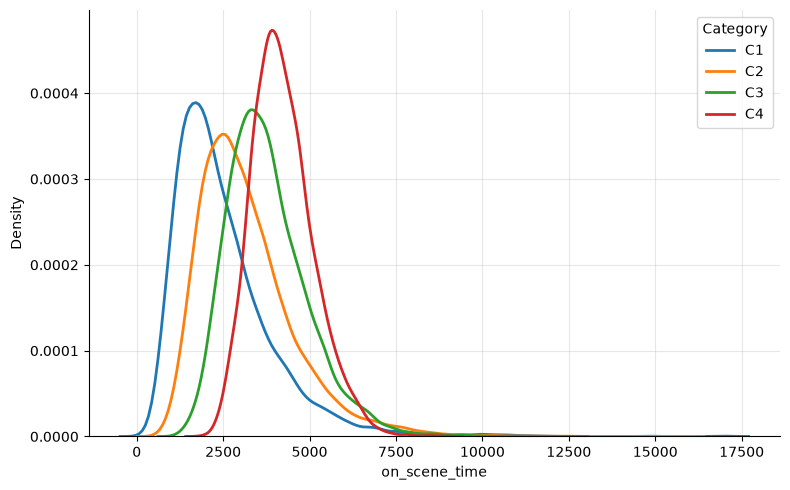

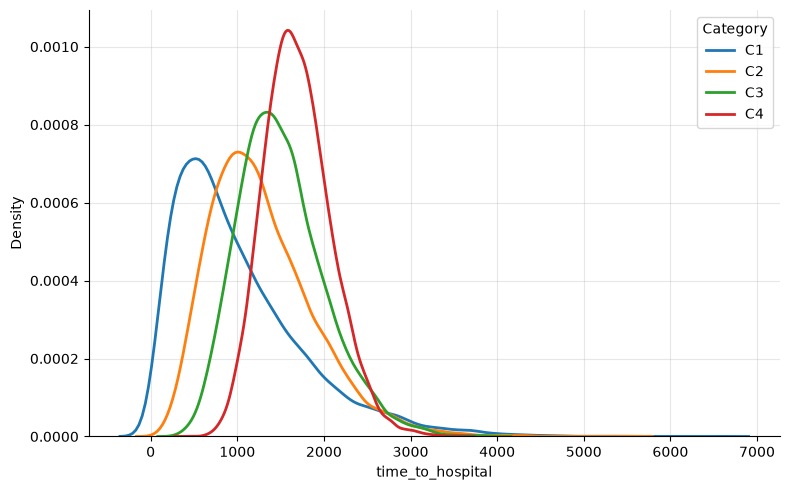

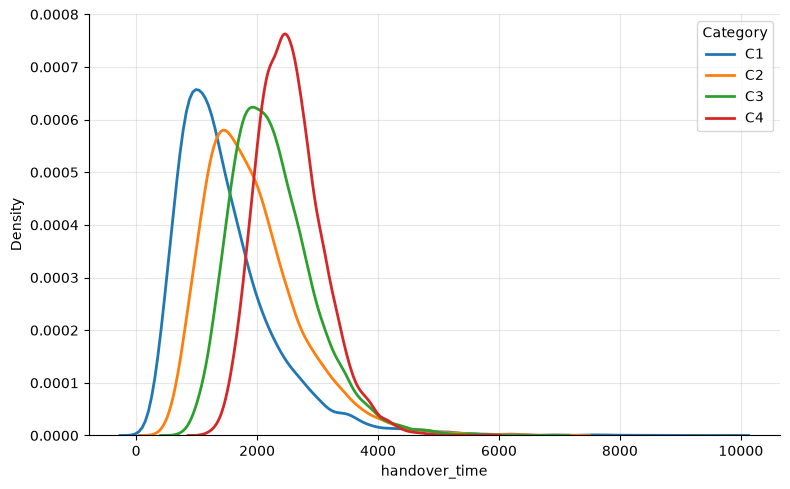

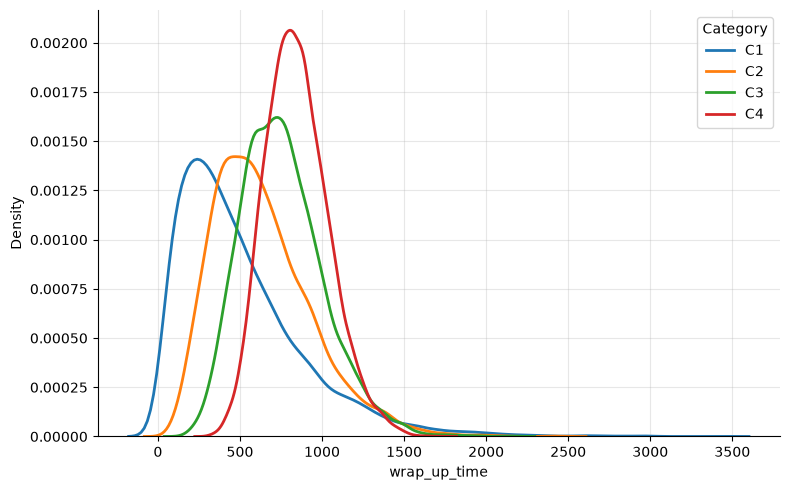

In [4]:
# Create distribution registry
registry = DistributionRegistry.create_batch(
    config, main_seed=42, preserve_structure=True
)

# Generate KDE plots for each metric, by response category
plot_metric_kde(metric="mobilisation_time", registry=registry)
plot_metric_kde(metric="time_to_scene", registry=registry)
plot_metric_kde(metric="on_scene_time", registry=registry)
plot_metric_kde(metric="time_to_hospital", registry=registry)
plot_metric_kde(metric="handover_time", registry=registry)
plot_metric_kde(metric="wrap_up_time", registry=registry)